In [1]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
PROJECT_NAME = "patch_icl_2d_exps"
DATASET = "biomedparse"  


dataset_configs = {
    "biomedparse": {"patch_icl": "8c24m0tp", "universeg": "dimsfnn4"},

}

runs = {k: {"wandb_name": v} for k, v in dataset_configs[DATASET].items()}
print(f"Dataset: {DATASET}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/dpxuser/.netrc.
wandb: Currently logged in as: tidiane to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset: biomedparse


In [ ]:
for run_name, run_data in runs.items():
    artifact = api.artifact(f"tidiane/{PROJECT_NAME}/run-{run_data['wandb_name']}-samples:v0")
    artifact.download()
    table = artifact.get("samples.table.json")
    runs[run_name]["df"] = table.get_dataframe()

df_all = pd.concat([df.assign(Run=name) for name, data in runs.items() for df in [data["df"]]], ignore_index=True)


In [4]:
print(f"Loaded {len(df_all)} samples, {df_all['dataset'].nunique()} datasets")

Loaded 358568 samples, 41 datasets


In [6]:
df_all.columns

Index(['dataset', 'sample_idx', 'label', 'dice_ds', 'dice_native',
       'dice_ds_soft', 'Run'],
      dtype='object')

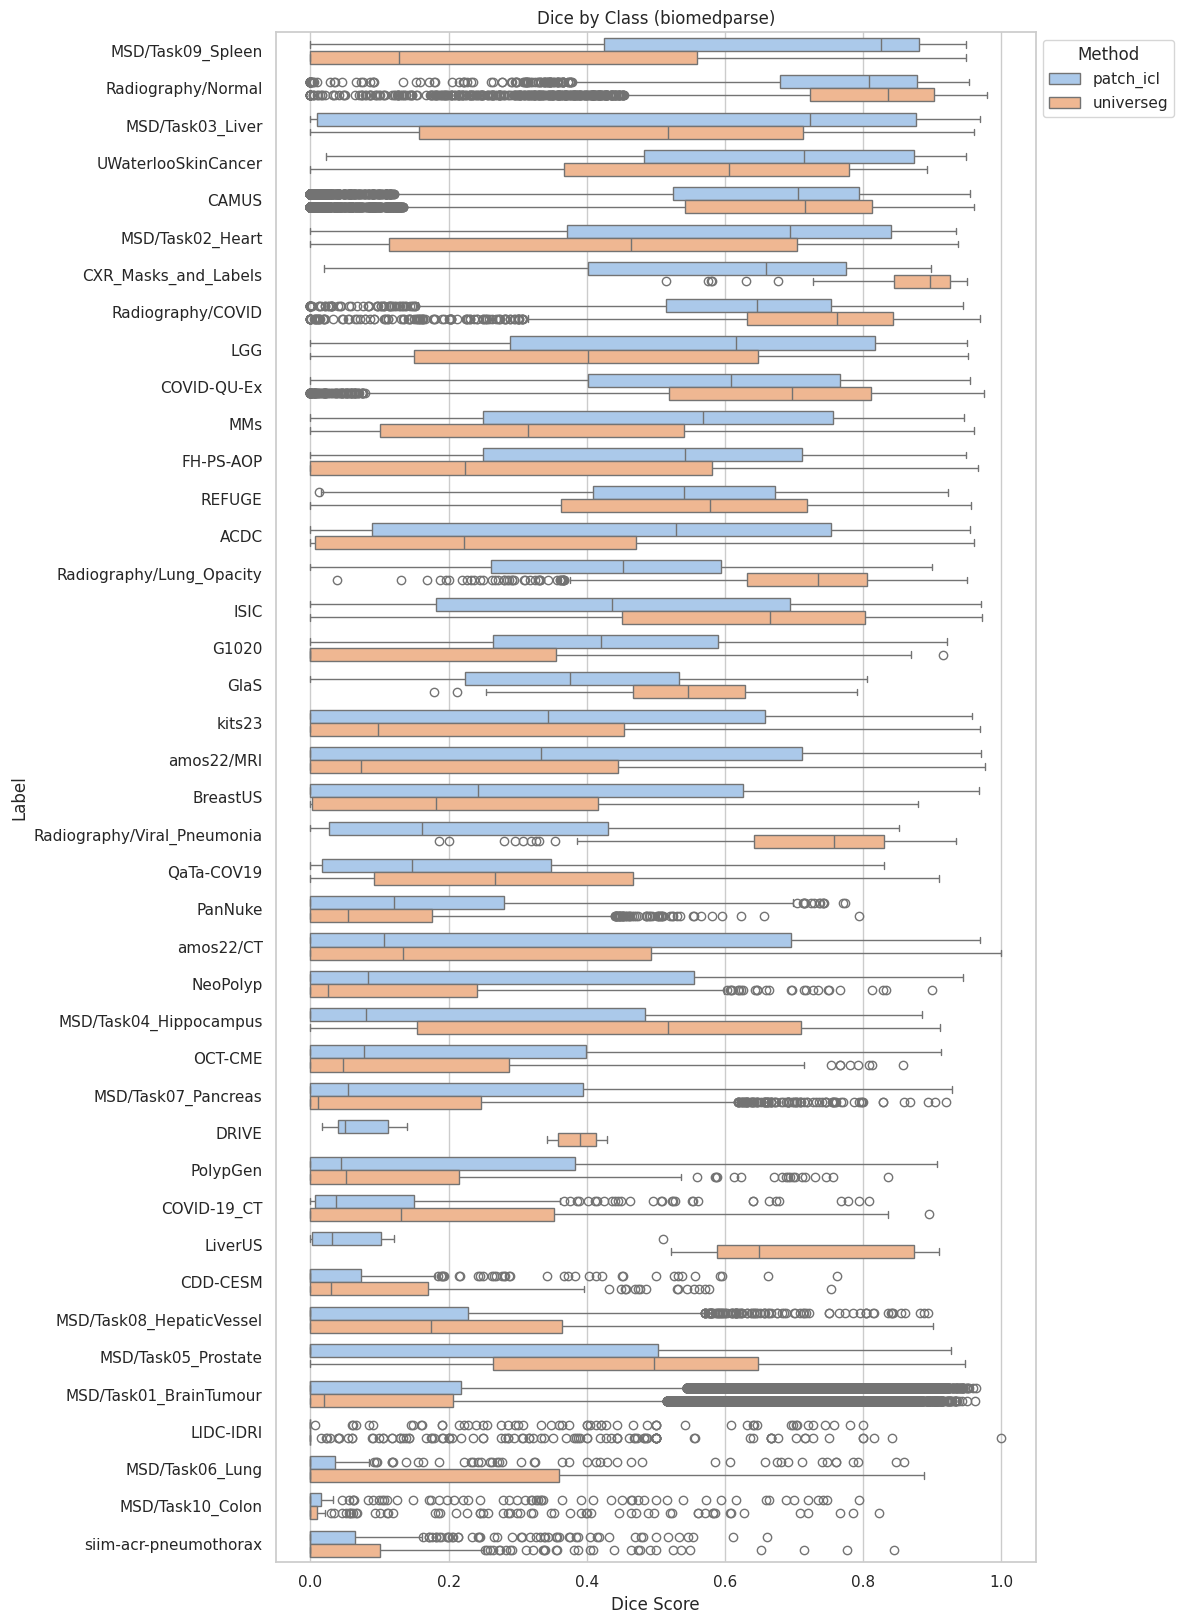


Dice results by label:

Label: MSD/Task09_Spleen
  Method: patch_icl    Mean: 0.6376  Std: 0.3456  N: 198
  Method: universeg    Mean: 0.2869  Std: 0.3254  N: 198

Label: Radiography/Normal
  Method: patch_icl    Mean: 0.7625  Std: 0.1511  N: 6117
  Method: universeg    Mean: 0.7834  Std: 0.1715  N: 6117

Label: MSD/Task03_Liver
  Method: patch_icl    Mean: 0.5512  Std: 0.3750  N: 5621
  Method: universeg    Mean: 0.4524  Std: 0.3011  N: 5621

Label: UWaterlooSkinCancer
  Method: patch_icl    Mean: 0.6589  Std: 0.2456  N: 65
  Method: universeg    Mean: 0.5548  Std: 0.2669  N: 65

Label: CAMUS
  Method: patch_icl    Mean: 0.5952  Std: 0.2865  N: 8328
  Method: universeg    Mean: 0.6423  Std: 0.2329  N: 8328

Label: MSD/Task02_Heart
  Method: patch_icl    Mean: 0.5842  Std: 0.3025  N: 248
  Method: universeg    Mean: 0.4326  Std: 0.3120  N: 248

Label: CXR_Masks_and_Labels
  Method: patch_icl    Mean: 0.5712  Std: 0.2617  N: 66
  Method: universeg    Mean: 0.8624  Std: 0.1001  N: 66

L

/tmp/ipykernel_5495/1652700306.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_all.groupby(['dataset', 'Run'])['dice_native'].agg(['mean', 'std', 'count']).reset_index()


In [7]:
# Boxplot comparison
sort_order = df_all[df_all['Run'] == 'patch_icl'].groupby('dataset')['dice_native'].median().sort_values(ascending=False).index
df_all['dataset'] = pd.Categorical(df_all['dataset'], categories=sort_order, ordered=True)

n_classes = df_all['dataset'].nunique()
fig_height = max(8, n_classes * 0.4)

plt.figure(figsize=(12, fig_height))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_all, x="dice_native", y="dataset", hue="Run", orient="h", palette="pastel", width=0.7)
plt.title(f'Dice by Class ({DATASET})')
plt.xlabel('Dice Score')
plt.ylabel('Label')
plt.legend(title='Method', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Print results by label (mean and std for each method)
print("\nDice results by label:")
summary = df_all.groupby(['dataset', 'Run'])['dice_native'].agg(['mean', 'std', 'count']).reset_index()
for label in sort_order:
    label_summary = summary[summary['dataset'] == label]
    if label_summary.empty:
        continue
    print(f"\nLabel: {label}")
    for _, row in label_summary.iterrows():
        print(f"  Method: {row['Run']:<12} Mean: {row['mean']:.4f}  Std: {row['std']:.4f}  N: {int(row['count'])}")

In [18]:
# metrics of corresponding training run (patch_icl_2d_exps/runs/umpdmm8e/)
train_run = api.run(f"tidiane/patch_icl_2d_exps_train/umpdmm8e")
metrics = train_run.summary
print(metrics.keys())

dict_keys(['_runtime', '_step', '_timestamp', '_wandb', 'dice/dataset/synth/annular/amb0.35', 'dice/dataset/synth/annular/amb0.45', 'dice/dataset/synth/annular/amb0.55', 'dice/dataset/synth/annular/amb0.65', 'dice/dataset/synth/annular/amb0.75', 'dice/dataset/synth/blob/amb0.35', 'dice/dataset/synth/blob/amb0.45', 'dice/dataset/synth/blob/amb0.55', 'dice/dataset/synth/blob/amb0.65', 'dice/dataset/synth/blob/amb0.75', 'dice/dataset/synth/elongated/amb0.35', 'dice/dataset/synth/elongated/amb0.45', 'dice/dataset/synth/elongated/amb0.55', 'dice/dataset/synth/elongated/amb0.65', 'dice/dataset/synth/elongated/amb0.75', 'dice/dataset/synth/scattered/amb0.35', 'dice/dataset/synth/scattered/amb0.45', 'dice/dataset/synth/scattered/amb0.55', 'dice/dataset/synth/scattered/amb0.65', 'dice/dataset/synth/scattered/amb0.75', 'dice/dataset/synth/tubular/amb0.35', 'dice/dataset/synth/tubular/amb0.45', 'dice/dataset/synth/tubular/amb0.55', 'dice/dataset/synth/tubular/amb0.65', 'dice/dataset/synth/tubular

dict_keys(['_runtime', '_step', '_timestamp', '_wandb', 'dice/dataset/synth/annular/amb0.35', 'dice/dataset/synth/annular/amb0.45', 'dice/dataset/synth/annular/amb0.55', 'dice/dataset/synth/annular/amb0.65', 'dice/dataset/synth/annular/amb0.75', 'dice/dataset/synth/blob/amb0.35', 'dice/dataset/synth/blob/amb0.45', 'dice/dataset/synth/blob/amb0.55', 'dice/dataset/synth/blob/amb0.65', 'dice/dataset/synth/blob/amb0.75', 'dice/dataset/synth/elongated/amb0.35', 'dice/dataset/synth/elongated/amb0.45', 'dice/dataset/synth/elongated/amb0.55', 'dice/dataset/synth/elongated/amb0.65', 'dice/dataset/synth/elongated/amb0.75', 'dice/dataset/synth/scattered/amb0.35', 'dice/dataset/synth/scattered/amb0.45', 'dice/dataset/synth/scattered/amb0.55', 'dice/dataset/synth/scattered/amb0.65', 'dice/dataset/synth/scattered/amb0.75', 'dice/dataset/synth/tubular/amb0.35', 'dice/dataset/synth/tubular/amb0.45', 'dice/dataset/synth/tubular/amb0.55', 'dice/dataset/synth/tubular/amb0.65', 'dice/dataset/synth/tubular

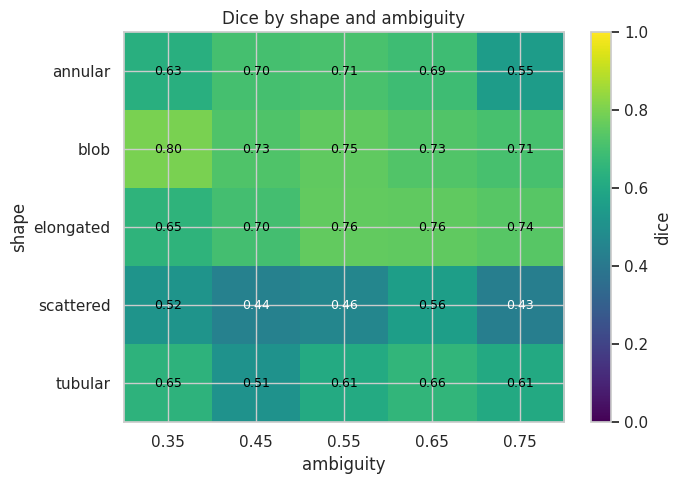

In [17]:
print(metrics.keys())
import numpy as np
import matplotlib.pyplot as plt

shapes = ['annular', 'blob', 'elongated', 'scattered', 'tubular']
ambs = ['0.35', '0.45', '0.55', '0.65', '0.75']

# Build matrix: rows = shapes, cols = amb values
M = np.array([[metrics[f'dice/dataset/synth/{s}/amb{a}'] for a in ambs]
              for s in shapes])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(M, cmap='viridis', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(ambs)), ambs)
ax.set_yticks(range(len(shapes)), shapes)
ax.set_xlabel('ambiguity')
ax.set_ylabel('shape')
ax.set_title('Dice by shape and ambiguity')

# annotate cells
for i in range(len(shapes)):
    for j in range(len(ambs)):
        ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center',
                color='white' if M[i, j] < 0.5 else 'black', fontsize=9)

fig.colorbar(im, ax=ax, label='dice')
plt.tight_layout()
plt.show()
